In [1]:
# import sys

# !{sys.executable} -m pip install pypyodbc

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import sys
import json
import shutil
from tqdm import tqdm
from pathlib import Path
import pandas as pd
import numpy as np
from ladybug.epw import EPW
from honeybee.config import folders
import matplotlib.pyplot as plt

# add the MPED code to the Path in order to access it in this notebook
sys.path.insert(0, Path("./").absolute().as_posix())

from masterplanenergydemand.mped import *
from masterplanenergydemand.utilities import *
from masterplanenergydemand.programs.ncm import load_access_tables

from masterplanenergydemand.buildings.building_types import BuildingType, BuildingTypes, Vintage, ConstructionType
from tqdm import tqdm

epw = EPW("./tests/test.epw")

In [19]:
# TODO - create CS by orientation and assign per orientation - including adding radiance parametrs too
# Use code form below as basiss, create list of CS
# ensure only one roof CS (or all the same and apply from first/last)
# https://github.com/ladybug-tools/honeybee-grasshopper-energy/blob/master/honeybee_grasshopper_energy/src/HB%20Apply%20Opaque%20Construction.py

# create a ConstutionSet
from honeybee_energy.constructionset import ConstructionSet
from honeybee.face import Floor, RoofCeiling, Aperture, Ground, Outdoors, Face
from honeybee.boundarycondition import Surface, Ground, Outdoors
from honeybee.orientation import angles_from_num_orient, face_orient_index, inputs_by_index
from honeybee_energy.construction.opaque import OpaqueConstruction
from honeybee_energy.construction.window import WindowConstruction

# define the number of angles that orientations can be categorised by. 8 for the city energy model
num_orient = 8
angles = angles_from_num_orient(num_orient)

# create the constructionsets to be applied per orientation, starting from north, giving a set of CSs one per orientation
construction_sets = []
for ang in angles:
    _id = cardinality(directions=num_orient, direction_angle=ang - (360 / num_orient / 2))
    construction_sets.append(ConstructionSet(identifier=_id))

# append and downward, and upward construction set to the end up the list of construction sets
construction_sets.append(ConstructionSet(identifier="Down"))
construction_sets.append(ConstructionSet(identifier="Up"))

# create the model to apply constructions to
model = Model.from_shoe_box(orientation_angle=45, window_ratio=0.15, width=3, depth=3, height=3)

# per orientation in the model, apply constructionset
for face in model.faces:
    face: Face
    
    # get index of orientation
    orient_i = face_orient_index(face, angles)

    # get the appropriate constructionset
    if orient_i is None:
        if isinstance(face.type, Floor):
            cset = construction_sets[-2]
        else:
            cset = construction_sets[-1]
    else:
        cset = construction_sets[orient_i]

    # get the constructions and modifiers to be applied
    wall_int_constr: OpaqueConstruction = cset.wall_set.interior_construction
    wall_ext_constr: OpaqueConstruction = cset.wall_set.exterior_construction
    wall_gnd_constr: OpaqueConstruction = cset.wall_set.ground_construction
    roofceil_int_constr: OpaqueConstruction = cset.roof_ceiling_set.interior_construction
    roofceil_ext_constr: OpaqueConstruction = cset.roof_ceiling_set.exterior_construction
    roofceil_gnd_constr: OpaqueConstruction = cset.roof_ceiling_set.ground_construction
    floor_int_constr: OpaqueConstruction = cset.floor_set.interior_construction
    floor_ext_constr: OpaqueConstruction = cset.floor_set.exterior_construction
    floor_gnd_constr: OpaqueConstruction = cset.floor_set.ground_construction
    window_int_constr: WindowConstruction = cset.aperture_set.interior_construction
    window_ext_constr: WindowConstruction = cset.aperture_set.window_construction
    skylight_construction: WindowConstruction = cset.aperture_set.skylight_construction
    
    if isinstance(face.type, Floor):
        if isinstance(face.boundary_condition, Surface):
            face.properties.energy.construction = floor_int_constr
            face.properties.radiance.modifier = floor_int_constr.to_radiance_visible_interior()
            for aperture in face.apertures:
                aperture.properties.energy.construction = window_int_constr
                aperture.properties.radiance.modifier = window_int_constr.to_radiance_visible()
        if isinstance(face.boundary_condition, Outdoors):
            face.properties.energy.construction = floor_ext_constr
            face.properties.radiance.modifier = floor_ext_constr.to_radiance_visible_exterior()
            for aperture in face.apertures:
                aperture.properties.energy.construction = window_ext_constr
                aperture.properties.radiance.modifier = window_ext_constr.to_radiance_visible()
        if isinstance(face.boundary_condition, Ground):
            face.properties.energy.construction = floor_gnd_constr
            face.properties.radiance.modifier = floor_gnd_constr.to_radiance_visible_interior()            

    if isinstance(face.type, RoofCeiling):
        if isinstance(face.boundary_condition, Surface):
            face.properties.energy.construction = roofceil_int_constr
            face.properties.radiance.modifier = roofceil_int_constr.to_radiance_visible_interior()
            for aperture in face.apertures:
                aperture.properties.energy.construction = window_int_constr
                aperture.properties.radiance.modifier = window_int_constr.to_radiance_visible()
        if isinstance(face.boundary_condition, Outdoors):
            face.properties.energy.construction = roofceil_ext_constr
            face.properties.radiance.modifier = roofceil_ext_constr.to_radiance_visible_exterior()
            for aperture in face.apertures:
                aperture.properties.energy.construction = window_ext_constr
                aperture.properties.radiance.modifier = window_ext_constr.to_radiance_visible()
        if isinstance(face.boundary_condition, Ground):
            face.properties.energy.construction = roofceil_gnd_constr
            face.properties.radiance.modifier = roofceil_gnd_constr.to_radiance_visible_interior()
        
    if isinstance(face.type, Wall):
        if isinstance(face.boundary_condition, Surface):
            face.properties.energy.construction = wall_int_constr
            face.properties.radiance.modifier = wall_int_constr.to_radiance_visible_interior()
            for aperture in face.apertures:
                aperture.properties.energy.construction = window_int_constr
                aperture.properties.radiance.modifier = window_int_constr.to_radiance_visible()
        if isinstance(face.boundary_condition, Outdoors):
            face.properties.energy.construction = wall_ext_constr
            face.properties.radiance.modifier = wall_ext_constr.to_radiance_visible_exterior()
        if isinstance(face.boundary_condition, Ground):
            face.properties.energy.construction = wall_gnd_constr
            face.properties.radiance.modifier = wall_gnd_constr.to_radiance_visible_interior()
    
        # for aperture in face.apertures:
        #     aperture: Aperture
            
        #     print(aperture.boundary_condition)
    # face.properties.energy.construction_set = construction_sets[orient_i]
#     face.con
#     print(orient_i, construction_sets[orient_i])
# construction_sets[0].to_radiance_solar_exterior()

# construction_sets
#     if orient_i is not None:
#         constr = inputs_by_index(orient_i, construction_sets)
#         face.constructionset = constr
# # Apply to a model based on face orientation
# face

N
E
S
W
None
0
1
2
3
None


In [7]:
BuildingType(**BuildingTypes.COURTHOUSE.value.to_dict())

BuildingType: Courthouse

In [30]:
temp = BuildingType(
    name="Hi",
    gross_floor_area=12000,
    floors=4,
    rotation=45,
    floor_to_floor_height=3.4,
    glazing_ratio=[0.1, 0.2, 0.1, 0.2, 0.1, 0.2, 0.1, 0.2]
)

temp._base_room().exterior_aperture_area / temp._base_room().exterior_wall_area

0.20000000000000007

In [14]:

tt = []
noms = []
pbar = tqdm(BuildingTypes, total=len(BuildingTypes))
for bt in pbar:
    pbar.set_description(str(bt))
    tt.append(bt.value.annual_hourly_load())
    noms.append(str(bt))
# BuildingTypes.RESIDENTIAL_LOWRISE.value.program()
# BuildingTypes.SCHOOL_PRIMARY.value.annual_hourly_load()["Electric Equipment (W/m2)"].plot()

# TODO - check setpoints for each!

BuildingTypes.LIBRARY: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:09<00:00,  3.46it/s]


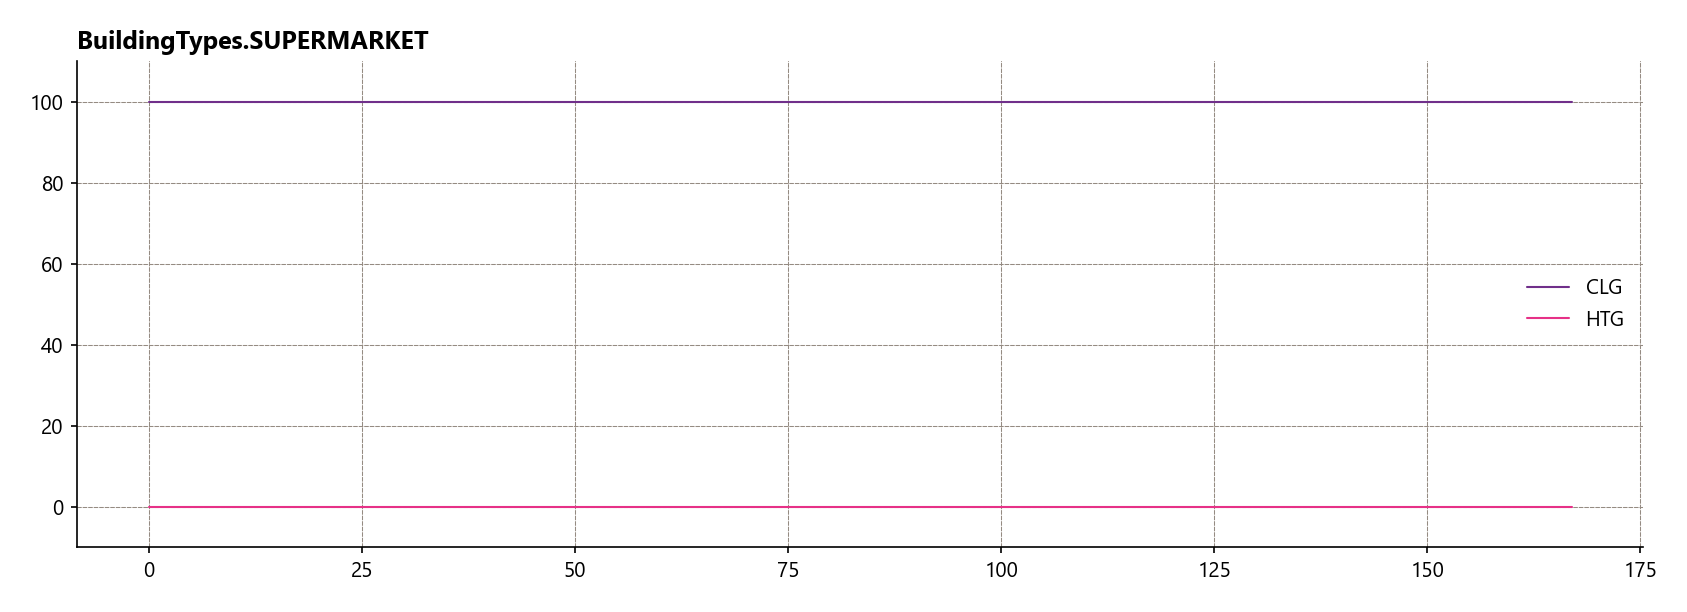

In [34]:
htg = pd.concat(tt, axis=1, keys=noms).filter(regex="Humidifying Setpoint").droplevel(1, axis=1)
htg = htg.groupby([htg.index.dayofweek, htg.index.hour]).mean()

clg = pd.concat(tt, axis=1, keys=noms).filter(regex="Dehumidifying Setpoint").droplevel(1, axis=1)
clg = clg.groupby([clg.index.dayofweek, clg.index.hour]).mean()

xx = pd.concat([htg, clg], keys=["HTG", "CLG"], axis=1).reorder_levels([1, 0], axis=1).sort_index(axis=1).reset_index(drop=True)
for col in xx.columns.get_level_values(0).unique():
    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    xx[col].plot(ax=ax, legend=True, title=col)

# Create custom gains/schedules and place into usable directories

In [141]:
import numpy as np
import pandas as pd
import pypyodbc
from honeybee.config import folders
from honeybee.typing import clean_string
from honeybee_energy.programtype import (ElectricEquipment, Lighting, People,
                                         ProgramType, ServiceHotWater,
                                         Setpoint, Ventilation)
from honeybee_energy.schedule.ruleset import (ScheduleDay, ScheduleRule,
                                              ScheduleRuleset,
                                              ScheduleTypeLimit)
from ladybug.dt import Date
from tqdm import tqdm
import calendar
import json
import logging
import shutil
from pathlib import Path

from honeybee_energy.material.opaque import EnergyMaterial
from honeybee_energy.construction.opaque import OpaqueConstruction
from honeybee_energy.construction.air import AirBoundaryConstruction
from honeybee_energy.construction.window import EnergyWindowMaterialGlazing, EnergyWindowFrame, EnergyWindowMaterialGas, WindowConstruction
from honeybee_energy.material.glazing import EnergyWindowMaterialGlazing, EnergyWindowMaterialSimpleGlazSys
from honeybee_energy.material.gas import EnergyWindowMaterialGas
from honeybee.typing import clean_string

In [138]:
DATA_PATH = Path(r"C:\Users\tgerrish\Documents\GitHub\BHoM\LadyBugTools_Prototypes\LadyBugTools_Prototype_Engine\Python\MasterplanEnergyDemand\masterplanenergydemand\data")

Processing Stand_Changing_Low: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 295/295 [00:37<00:00,  7.93it/s]


'Stand_Changing'

In [197]:
d = load_access_tables(DATA_PATH / "NCM_db_activity_public_15Dec21.mdb")

temperature_type_limit = ScheduleTypeLimit(
    identifier="Temperature", numeric_type="Continuous", unit_type="Temperature"
)
month_lookup = {calendar.month_abbr[i].title(): i for i in range(1, 13, 1)}

programs: list[ProgramType] = []
names = []
pbar = tqdm(list(d["activity"].iterrows())[0:])
for _, row in pbar:
    pbar.set_description(f"Processing {row.NAME}")
    
    # region: SETPOINT
    heat_multiple = d["annual_weekly_schedules"][
        d["annual_weekly_schedules"].ANNUAL_SCHEDULE == row.HEAT_SET_SCH
    ]
    end_date = None
    day_schedules = {}
    rules = []
    for n, (_, _row) in enumerate(list(heat_multiple.iterrows())):
        wk_sched = d["weekly_schedules"][
            d["weekly_schedules"].ID == _row.WEEKLY_SCHEDULE
        ]
        start_date = Date() if n == 0 else end_date
        end_date = Date(month=month_lookup[_row.END_MONTH], day=int(_row.END_DAY))
        for day in DAYS:
            day_schedule_series = d["daily_schedules"][
                d["daily_schedules"].ID == wk_sched.squeeze()[day]
            ].squeeze()
            day_schedule_series = ScheduleDay.from_values_at_timestep(
                identifier=clean_string(f"NCM_{day_schedule_series.NAME}_{day}"),
                values=[
                    np.nan_to_num(day_schedule_series[f"h{i:02d}"], nan=100)
                    for i in range(24)
                ],
                timestep=1,
            ).duplicate()
            if day != "HOLIDAY":
                rule = ScheduleRule(
                    **{
                        "schedule_day": day_schedule_series,
                        f"apply_{day.lower()}": True,
                        "end_date": end_date,
                        "start_date": start_date,
                    }
                )
                rules.append(rule)
            day_schedules[day] = day_schedule_series
    default_day = day_schedules["MONDAY"].duplicate()
    heating_schedule = ScheduleRuleset(
        identifier=clean_string(f"NCM_{row.NAME}_Heating_Schedule"),
        default_day_schedule=default_day,
        schedule_rules=rules,
        schedule_type_limit=temperature_type_limit,
    )

    cool_multiple = d["annual_weekly_schedules"][
        d["annual_weekly_schedules"].ANNUAL_SCHEDULE == row.COOL_SET_SCH
    ]
    end_date = None
    day_schedules = {}
    rules = []
    for n, (_, _row) in enumerate(list(cool_multiple.iterrows())):
        wk_sched = d["weekly_schedules"][
            d["weekly_schedules"].ID == _row.WEEKLY_SCHEDULE
        ]
        start_date = Date() if n == 0 else end_date
        end_date = Date(month=month_lookup[_row.END_MONTH], day=int(_row.END_DAY))

        for day in DAYS:
            day_schedule_series = d["daily_schedules"][
                d["daily_schedules"].ID == wk_sched.squeeze()[day]
            ].squeeze()
            day_schedule_series = ScheduleDay.from_values_at_timestep(
                identifier=clean_string(f"NCM_{day_schedule_series.NAME}_{day}"),
                values=[
                    np.nan_to_num(day_schedule_series[f"h{i:02d}"], nan=100)
                    for i in range(24)
                ],
                timestep=1,
            ).duplicate()
            if day != "HOLIDAY":
                rule = ScheduleRule(
                    **{
                        "schedule_day": day_schedule_series,
                        f"apply_{day.lower()}": True,
                        "end_date": end_date,
                        "start_date": start_date,
                    }
                )
                rules.append(rule)
            day_schedules[day] = day_schedule_series
    default_day = day_schedules["MONDAY"].duplicate()
    cooling_schedule = ScheduleRuleset(
        identifier=clean_string(f"NCM_{row.NAME}_Cooling_Schedule"),
        default_day_schedule=default_day,
        schedule_rules=rules,
        schedule_type_limit=temperature_type_limit,
    )

    humidifying_schedule = ScheduleRuleset.from_constant_value(
        identifier=clean_string(f"NCM_{row.NAME}_Humidifying_Schedule"),
        value=row.HUM_MIN,
    )
    dehumidifying_schedule = ScheduleRuleset.from_constant_value(
        identifier=clean_string(f"NCM_{row.NAME}_Dehumidifying_Schedule"),
        value=row.HUM_MAX,
    )

    setpoint = Setpoint(
        identifier=clean_string(f"NCM_{row.NAME}_Setpoint"),
        cooling_schedule=cooling_schedule,
        heating_schedule=heating_schedule,
        humidifying_schedule=humidifying_schedule,
        dehumidifying_schedule=dehumidifying_schedule,
    )
    # endregion

    # region: PEOPLE
    occ_multiple = d["annual_weekly_schedules"][
        d["annual_weekly_schedules"].ANNUAL_SCHEDULE == row.OCCUPANCY_SCH
    ]
    end_date = None
    day_schedules = {}
    rules = []
    for n, (_, _row) in enumerate(list(occ_multiple.iterrows())):
        wk_sched = d["weekly_schedules"][
            d["weekly_schedules"].ID == _row.WEEKLY_SCHEDULE
        ]
        start_date = Date() if n == 0 else end_date
        end_date = Date(month=month_lookup[_row.END_MONTH], day=int(_row.END_DAY))
        for day in DAYS:
            day_schedule_series = d["daily_schedules"][
                d["daily_schedules"].ID == wk_sched.squeeze()[day]
            ].squeeze()
            day_schedule_series = ScheduleDay.from_values_at_timestep(
                identifier=clean_string(f"NCM_{day_schedule_series.NAME}_{day}"),
                values=[
                    np.nan_to_num(day_schedule_series[f"h{i:02d}"], nan=100)
                    for i in range(24)
                ],
                timestep=1,
            ).duplicate()
            if day != "HOLIDAY":
                rule = ScheduleRule(
                    **{
                        "schedule_day": day_schedule_series,
                        f"apply_{day.lower()}": True,
                        "end_date": end_date,
                        "start_date": start_date,
                    }
                )
                rules.append(rule)
            day_schedules[day] = day_schedule_series
    default_day = day_schedules["MONDAY"].duplicate()
    occupancy_schedule = ScheduleRuleset(
        identifier=clean_string(f"NCM_{row.NAME}_Schedule"),
        default_day_schedule=default_day,
        schedule_rules=rules,
    )
    activity_schedule = ScheduleRuleset.from_constant_value(
        identifier=clean_string(f"NCM_{row.NAME}_Activity_Schedule"),
        value=row.METABOLIC_RATE,
    )
    people = People(
        identifier=clean_string(f"NCM_{row.NAME}_People"),
        people_per_area=row.OCCUPANCY_DENS,
        occupancy_schedule=occupancy_schedule,
        latent_fraction=row.OCCUP_PERC_LAT / 100,
        activity_schedule=activity_schedule,
    )

    # endregion

    # region: LIGHTING
    temp = d["annual_weekly_schedules"][
        d["annual_weekly_schedules"].ANNUAL_SCHEDULE == row.LIGHTING_SCH
    ]
    end_date = None
    day_schedules = {}
    rules = []
    for n, (_, _row) in enumerate(list(temp.iterrows())):
        wk_sched = d["weekly_schedules"][
            d["weekly_schedules"].ID == _row.WEEKLY_SCHEDULE
        ]
        start_date = Date() if n == 0 else end_date
        end_date = Date(month=month_lookup[_row.END_MONTH], day=int(_row.END_DAY))
        for day in DAYS:
            day_schedule_series = d["daily_schedules"][
                d["daily_schedules"].ID == wk_sched.squeeze()[day]
            ].squeeze()
            day_schedule_series = ScheduleDay.from_values_at_timestep(
                identifier=clean_string(f"NCM_{day_schedule_series.NAME}_{day}"),
                values=[
                    np.nan_to_num(day_schedule_series[f"h{i:02d}"], nan=100)
                    for i in range(24)
                ],
                timestep=1,
            ).duplicate()
            if day != "HOLIDAY":
                rule = ScheduleRule(
                    **{
                        "schedule_day": day_schedule_series,
                        f"apply_{day.lower()}": True,
                        "end_date": end_date,
                        "start_date": start_date,
                    }
                )
                rules.append(rule)
            day_schedules[day] = day_schedule_series
    default_day = day_schedules["MONDAY"].duplicate()
    lighting_schedule = ScheduleRuleset(
        identifier=f"NCM_{clean_string(row.NAME)}_Lighting_Schedule",
        default_day_schedule=default_day,
        schedule_rules=rules,
    )
    if row.LIGHTING_DISPLAY == 0 and row.LIGHTING_LUX != 0:
        luminous_efficacy = 100
        lighting = Lighting(
            identifier=clean_string(f"NCM_{row.NAME}_Lighting"),
            watts_per_area=np.nan_to_num(row.LIGHTING_LUX, nan=0)
            / luminous_efficacy,
            schedule=lighting_schedule,
        )
    else:
        lighting = Lighting(
            identifier=clean_string(f"NCM_{row.NAME}_Lighting"),
            watts_per_area=np.nan_to_num(row.LIGHTING_DISPLAY, nan=0),
            schedule=lighting_schedule,
        )
    # endregion

    # region: EQUIPMENT
    equip = d["annual_weekly_schedules"][
        d["annual_weekly_schedules"].ANNUAL_SCHEDULE == row.EQUIPMENT_SCH
    ]
    end_date = None
    day_schedules = {}
    rules = []
    for n, (_, _row) in enumerate(list(equip.iterrows())):
        wk_sched = d["weekly_schedules"][
            d["weekly_schedules"].ID == _row.WEEKLY_SCHEDULE
        ]
        start_date = Date() if n == 0 else end_date
        end_date = Date(month=month_lookup[_row.END_MONTH], day=int(_row.END_DAY))
        for day in DAYS:
            day_schedule_series = d["daily_schedules"][
                d["daily_schedules"].ID == wk_sched.squeeze()[day]
            ].squeeze()
            day_schedule_series = ScheduleDay.from_values_at_timestep(
                identifier=clean_string(f"NCM_{day_schedule_series.NAME}_{day}"),
                values=[
                    np.nan_to_num(day_schedule_series[f"h{i:02d}"], nan=100)
                    for i in range(24)
                ],
                timestep=1,
            ).duplicate()
            if day != "HOLIDAY":
                rule = ScheduleRule(
                    **{
                        "schedule_day": day_schedule_series,
                        f"apply_{day.lower()}": True,
                        "end_date": end_date,
                        "start_date": start_date,
                    }
                )
                rules.append(rule)
            day_schedules[day] = day_schedule_series
    default_day = day_schedules["MONDAY"].duplicate()
    equipment_schedule = ScheduleRuleset(
        identifier=clean_string(f"NCM_{row.NAME}_Equipment_Schedule"),
        default_day_schedule=default_day,
        schedule_rules=rules,
    )
    equipment = ElectricEquipment(
        identifier=clean_string(f"NCM_{row.NAME}_Equipment"),
        watts_per_area=np.nan_to_num(row.EQUIPMENT_W_M2, nan=0),
        schedule=equipment_schedule,
        latent_fraction=np.nan_to_num(row.EQUIP_PERC_LAT, nan=0) / 100,
    )
    # endregion

    # region: VENTILATION
    ventilation = Ventilation(
        identifier=clean_string(f"NCM_{row.NAME}_Ventilation"),
        flow_per_person=np.nan_to_num(row.OA_FLOW_PERSON, nan=0) * 0.001,
        schedule=occupancy_schedule,
    )
    # endregion

    # region: HOTWATER
    # TODO - distribute hot water usage over the day according to occupancy, not every hour
    service_hot_water = ServiceHotWater(
        identifier=clean_string(f"NCM_{row.NAME}_HotWater"),
        flow_per_area=np.nan_to_num(row.HWS, nan=0) / 24,
        schedule=occupancy_schedule,
    )
    # endregion

    program = ProgramType(
        identifier=clean_string(f"NCM_{row.NAME}"),
        electric_equipment=equipment,
        lighting=lighting,
        people=people,
        service_hot_water=service_hot_water,
        setpoint=setpoint,
        ventilation=ventilation,
    )
    programs.append(program)
    names.append(row.ORIGINAL_NAME)




Processing Stand_Changing_Low: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 295/295 [00:47<00:00,  6.19it/s]


In [202]:
xxx = pd.DataFrame([names, programs], index=["NAME", "PROGRAM"]).T
xxx[xxx.NAME == None]

,NAME,PROGRAM


In [96]:


# create materials dataset
d = load_access_tables(DATA_PATH / "NCM_db_construction_public_29Apr22.mdb")

face_type_ref = dict(d["construction_envelope"].values)
face_cat_ref = dict(d["construction_category"].values[:, :2])
roughness_ref = {
    1: "VeryRough",
    2: "Rough",
    3: "MediumRough",
    4: "MediumSmooth",
    5: "Smooth", 
    6: "VerySmooth",
}
source_ref = dict(d["data_sources"].values[:, :2])

sectors = []
dates = []
types = []
names = []
faces = []
constructions = []

errs = []
for c in ["Wall", "Roof", "Floor", "Door"]:
    pbar = tqdm(list(d[f"ConstbySectorDate{c}"].iterrows()))
    for _, row in pbar:
        pbar.set_description(row["CONSTRUCTION"])
        try:
            sector = row["Sector"]
            date = row["Date"]
            _type = row["GD"]
            name = row["CONSTRUCTION"]
        
            constr_id = d[f"i_{c.lower()}"][d[f"i_{c.lower()}"].ID == row.C_ID].CONSTRUCTION.values[0]
            layers_id = d["constructions"][d["constructions"].ID == constr_id].LAYERS.values[0]
            roughness = roughness_ref[d["constructions"][d["constructions"].ID == constr_id]["SURFACE-ROUGHNESS"].values[0]]
        
            layer_materials = d["layer_materials"][d["layer_materials"].LAYER == layers_id]
            if len(layer_materials) < 1:
                continue
            materials = []
            for _, layer_material in layer_materials.iterrows():
                # get material from material table
                mat = d["materials"][d["materials"].ID == layer_material.MATERIAL1].squeeze()
                if mat.TYPE == "PROPERTIES":
                    # normal material
                    material = EnergyMaterial(
                        identifier=clean_string(f"NCM_{mat.NAME}"),
                        thickness=layer_material.TH / 1000,
                        conductivity=mat.COND,
                        specific_heat=mat["S-H"],
                        density=mat.DENS,
                        roughness=roughness,
                    )
                else:
                    # air gap material
                    material = EnergyMaterial(
                        identifier=clean_string(f"NCM_{mat.NAME}"),
                        thickness=layer_material.TH / 1000,
                        conductivity=0.556,
                        specific_heat=1000,
                        density=1.28,
                        roughness="Smooth",
                    )
                materials.append(material)
            constr = OpaqueConstruction(identifier=clean_string(f"NCM_{name}"), materials=materials)
            constructions.append(constr)
        
            sectors.append(sector)
            dates.append(date)
            types.append(_type)
            faces.append(c)
            names.append(name)
        except Exception as e:
            errs.append((name, e))

df = pd.DataFrame([sectors, dates, types, faces, names, constructions], index=["SECTOR", "DATE", "TYPE", "FACE", "NAME", "CONSTRUCTION"]).T


Personnel door (E&W) 2002/06 Part L: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 266/266 [00:00<00:00, 287.97it/s]


In [168]:
# TODO -  add classification against internal/external for creation of constructionsets
df.head()

# save constructions to separate files to help organise
for _, row in df.groupby([df.SECTOR, df.DATE, df.FACE], as_index=False).agg(lambda x: set(x)).iterrows():
    name = clean_string(f"NCM_{row.SECTOR.replace(' ', '')}_{row.DATE.replace(' ', '')}_{row.FACE.replace(' ', '')}")
    with open(DATA_PATH / "custom_standards" / "constructions" / f"{name}.json", "w") as fp:
        json.dump({clean_string(f"NCM_{row.SECTOR.replace(' ', '')}_{row.DATE.replace(' ', '')}_{row.FACE.replace(' ', '')}"): i.to_dict() for i in row.CONSTRUCTION}, fp, indent=4)
    


In [185]:
abc.SECTOR.unique()

array(['Industrial', 'Retail', 'Leisure', 'Office', 'Hotels', 'Health',
       'Education'], dtype=object)

In [191]:
for date in df.DATE.unique():
    abc = df[df.DATE == date]
    d0 = DATA_PATH / "custom_standards" / "constructions" / f"NCM_{date}"
    d0.mkdir(parents=True, exist_ok=True)
    for sector in abc.SECTOR.unique():
        bcd = abc[abc.SECTOR == sector]
        ff = d0 / f"NCM_{sector}.json"
        # get constructions to save into json
        with open(ff, "w") as fp:
            json.dump({i.identifier: i.to_dict() for i in bcd.CONSTRUCTION}, fp, indent=4)
        # print(ff)


In [130]:
d = load_access_tables(r"C:\Users\tgerrish\Documents\GitHub\BHoM\LadyBugTools_Prototypes\LadyBugTools_Prototype_Engine\Python\MasterplanEnergyDemand\masterplanenergydemand\data\NCM_db_glazing_public_29Apr22.mdb")

# create frames/glazings
errs = []
frames = []
pbar = tqdm(list(d["frames"].iterrows()))
for _, row in pbar:
    pbar.set_description(row.NAME)
    frames.append(EnergyWindowFrame(identifier=clean_string(row.NAME), conductance=row.CONDUCTANCE, width=row.WIDTH / 1000 if row.WIDTH else 0.0345))

windows = []
pbar = tqdm(list(d["glazings"].iterrows()))
for _, row in pbar:
    pbar.set_description(row.NAME)
    try:
        layers = ["P1", "G1", "P2", "G2", "P3", "G3", "P4"]
        materials = []
        for layer in layers:
            if not np.isnan(row[layer]):
                if "G" in layer:
                    gas = d["windowgas"][d["windowgas"].ID == row[layer]].squeeze()
                    gas_type = "Argon" if "argon" in gas.Name.lower() else "Air"
                    mat = EnergyWindowMaterialGas(identifier=clean_string(f"{gas.Name}"), gas_type=gas_type, thickness=gas.Thickness / 1000)
                else:
                    pane = d["panes"][d["panes"].ID == row[layer]].squeeze()
                    mat = EnergyWindowMaterialGlazing(
                        identifier=clean_string(f"{pane.Name}"), 
                        conductivity=pane.Conductivity, 
                        thickness=pane.Thickness, 
                        solar_transmittance=pane["Solar transmittance"], 
                        solar_reflectance=np.nan_to_num(pane["Outside solar reflectance"], nan=0.075), 
                        visible_transmittance=np.nan_to_num(pane["Visible transmittance"], nan=0.53), 
                        infrared_transmittance=np.nan_to_num(pane["Infra red transmittance"], nan=0), 
                        emissivity=np.nan_to_num(pane["Outside Infra Red reflectance"], nan=0.84), 
                        emissivity_back=np.nan_to_num(pane["Inside Infra Red reflectance"], nan=0.84), 
                        visible_reflectance=np.nan_to_num(pane["Outside Visible reflectance"], nan=0.075),
                    )
                materials.append(mat)
        windows.append(
            WindowConstruction(identifier=clean_string(f"NCM_{row.NAME}"), materials=materials)
        )
    except Exception as e:
        continue

Triple glazing (SCO) 2002-2006 (metal frame): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:00<00:00, 304.38it/s]


In [37]:
from openpyxl.worksheet.table import Table
from openpyxl.utils import get_column_letter

out_dir = Path(r"C:\Users\tgerrish\Downloads")

mdb_files = [
    r"C:\Users\tgerrish\Documents\GitHub\BHoM\LadyBugTools_Prototypes\LadyBugTools_Prototype_Engine\Python\MasterplanEnergyDemand\masterplanenergydemand\data\NCM_db_activity_public_15Dec21.mdb",
    r"C:\Users\tgerrish\Documents\GitHub\BHoM\LadyBugTools_Prototypes\LadyBugTools_Prototype_Engine\Python\MasterplanEnergyDemand\masterplanenergydemand\data\NCM_db_construction_public_29Apr22.mdb",
    r"C:\Users\tgerrish\Documents\GitHub\BHoM\LadyBugTools_Prototypes\LadyBugTools_Prototype_Engine\Python\MasterplanEnergyDemand\masterplanenergydemand\data\NCM_db_glazing_public_29Apr22.mdb",
]
for mdb_file in mdb_files:
    mdb_file = Path(mdb_file)
    d = load_access_tables(mdb_file)
    with pd.ExcelWriter(out_dir / mdb_file.with_suffix(".xlsx").name) as writer: 
        for k, v in list(d.items())[0:]:
            v.columns = [str(i) for i in v.columns]
            v.to_excel(writer, sheet_name=k)
            workbook = writer.book
            worksheet = writer.sheets[k]
            table = Table(displayName=k, ref="A1:" + get_column_letter(worksheet.max_column) + str(worksheet.max_row))
            worksheet.add_table(table)

Loading data from weekly_schedules: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 31/31 [00:00<00:00, 49.72it/s]
C:\ProgramData\BHoM\Extensions\PythonEnvironments\LadybugTools_Toolkit\lib\site-packages\openpyxl\worksheet\_writer.py:274: UserWarning: File may not be readable: column headings must be strings.
  warn("File may not be readable: column headings must be strings.")
Loading data from windowgas_category: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 23/23 [00:00<00:00, 612.24it/s]


In [31]:
help(worksheet.add_table)

Help on method add_table in module openpyxl.worksheet.worksheet:

add_table(table) method of openpyxl.worksheet.worksheet.Worksheet instance
    Check for duplicate name in definedNames and other worksheet tables
    before adding table.



In [27]:
from honeybee_energy.material.opaque import EnergyMaterial
from honeybee_energy.construction.opaque import OpaqueConstruction
from honeybee_energy.construction.air import AirBoundaryConstruction



for _, row in list(d["AllConstructionsbyCategory_NCM"].iterrows())[0:2]:
    construction_name = row.CONSTRUCTION
    construction_id = row.C_ID

    # get construction layers
    layers_id = d["constructions"][d["constructions"].ID == construction_id].LAYERS
    if len(layers_id) != 1:
        raise ValueError(f"More than one layer id assigned to construction. Something is wrong with {construction_name}")
    else:
        layers_id = layers_id.values[0]

    # get layer materials
    
    
    # layers_id = row.LAYERS
    # d["layers"][d["layers"].ID == layers_id]
    pass
# row
construction_name, layers_id
# d["constructions"][d["constructions"].ID == construction_id]

Loading data from roughness: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:00<00:00, 279.60it/s]


('Cast concrete wall, internal insulation', 197)

In [ ]:
row

CATEGORY                                                            30
NAME                    Solid brick wall, 225 mm, uninsulated Pre 1919
TYPE                                                                 2
TYPE-ENV                                                             1
LAYERS                                                             180
U-VALUE                                                            1.7
U-VALUE-CALC                                                       1.7
SURFACE-ROUGHNESS                                                  3.0
ABSORTIVITY                                                        0.7
DESCRIPTION          Existing solid wall, with no insulation added,...
SOURCE                                                              30
ID                                                                 837
CM1                                                              135.0
CM2                                                              135.0
CM1-CA

In [3]:
# create programs
from honeybee_energy.programtype import ProgramType, People, Lighting, Setpoint, ServiceHotWater, ElectricEquipment, GasEquipment, Ventilation
from honeybee.typing import clean_and_id_string, clean_string
from honeybee_energy.schedule.ruleset import ScheduleDay, ScheduleRuleset, ScheduleTypeLimit, ScheduleRule, ScheduleRulesetProperties
from ladybug.dt import Date
import calendar

programs = []
err = []
pbar = tqdm(list(d["activity"].iterrows())[0:])
for idx, row in pbar:
    pbar.set_description(f"Processing {row.NAME}")
    
    # setpoint
    ## heating schedule
    temp = d["annual_weekly_schedules"][d["annual_weekly_schedules"].ANNUAL_SCHEDULE == row.HEAT_SET_SCH]
    if len(temp) != 1:
        err.append(row)
        continue
    ### create annual schedule for heating
    wk = d["weekly_schedules"][d["weekly_schedules"].ID == temp.WEEKLY_SCHEDULE.values[0]].squeeze()
    #### get schedule type limit
    sch_type = d["schedules_type"][d["schedules_type"].ID == wk.TYPE].squeeze().COD
    schedule_type_limit = ScheduleTypeLimit(identifier="Temperature", numeric_type="Continuous", unit_type="Temperature")
    #### get schedules for each day
    xx = {}
    for day in ["MONDAY", "TUESDAY", "WEDNESDAY", "THURSDAY", "FRIDAY", "SATURDAY", "SUNDAY", "HOLIDAY"]:
        day_temp = d["daily_schedules"][d["daily_schedules"].ID == wk[day]].squeeze()
        xx[day] = ScheduleDay.from_values_at_timestep(identifier=clean_and_id_string(day_temp.NAME), values=[np.nan_to_num(day_temp[f"h{i:02d}"], nan=0) for i in range(24)], timestep=1)
    #### create schedule ruleset
    heating_schedule = ScheduleRuleset.from_week_day_schedules(
        identifier=clean_and_id_string(wk.NAME), 
        monday_schedule=xx["MONDAY"], 
        tuesday_schedule=xx["TUESDAY"], 
        wednesday_schedule=xx["WEDNESDAY"], 
        thursday_schedule=xx["THURSDAY"], 
        friday_schedule=xx["FRIDAY"], 
        saturday_schedule=xx["SATURDAY"], 
        sunday_schedule=xx["SUNDAY"], 
        holiday_schedule=xx["HOLIDAY"], 
        summer_designday_schedule=xx["MONDAY"], 
        winter_designday_schedule=xx["MONDAY"], 
        schedule_type_limit=schedule_type_limit
    )

    ## cooling schedule
    temp = d["annual_weekly_schedules"][d["annual_weekly_schedules"].ANNUAL_SCHEDULE == row.COOL_SET_SCH]
    if len(temp) != 1:
        err.append(row)
        continue
    ### create annual schedule for cooling
    wk = d["weekly_schedules"][d["weekly_schedules"].ID == temp.WEEKLY_SCHEDULE.values[0]].squeeze()
    #### get schedule type limit
    schedule_type_limit = ScheduleTypeLimit(identifier="Temperature", numeric_type="Continuous", unit_type="Temperature")
    #### get schedules for each day
    xx = {}
    for day in ["MONDAY", "TUESDAY", "WEDNESDAY", "THURSDAY", "FRIDAY", "SATURDAY", "SUNDAY", "HOLIDAY"]:
        day_temp = d["daily_schedules"][d["daily_schedules"].ID == wk[day]].squeeze()
        xx[day] = ScheduleDay.from_values_at_timestep(identifier=clean_and_id_string(day_temp.NAME), values=[np.nan_to_num(day_temp[f"h{i:02d}"], nan=100) for i in range(24)], timestep=1)
    #### create schedule ruleset
    cooling_schedule = ScheduleRuleset.from_week_day_schedules(
        identifier=clean_and_id_string(wk.NAME), 
        monday_schedule=xx["MONDAY"], 
        tuesday_schedule=xx["TUESDAY"], 
        wednesday_schedule=xx["WEDNESDAY"], 
        thursday_schedule=xx["THURSDAY"], 
        friday_schedule=xx["FRIDAY"], 
        saturday_schedule=xx["SATURDAY"], 
        sunday_schedule=xx["SUNDAY"], 
        holiday_schedule=xx["HOLIDAY"], 
        summer_designday_schedule=xx["MONDAY"], 
        winter_designday_schedule=xx["MONDAY"], 
        schedule_type_limit=schedule_type_limit
    )

    ## humidifying/dehumidifying schedule constant
    humidifying_schedule = ScheduleRuleset.from_constant_value(identifier=clean_and_id_string(f"{row.NAME}_Humidifying"), value=row.HUM_MIN)
    dehumidifying_schedule = ScheduleRuleset.from_constant_value(identifier=clean_and_id_string(f"{row.NAME}_Dehumidifying"), value=row.HUM_MAX)
    
    ## create setpoint object
    setpoint = Setpoint(
        identifier=clean_and_id_string(f"{row.NAME}_Setpoint"), 
        cooling_schedule=cooling_schedule, 
        heating_schedule=heating_schedule, 
        humidifying_schedule=humidifying_schedule, 
        dehumidifying_schedule=dehumidifying_schedule
    )

    # create occupant gain
    ## occupant schedule
    temp = d["annual_weekly_schedules"][d["annual_weekly_schedules"].ANNUAL_SCHEDULE == int(row.OCCUPANCY_SCH)]
    if len(temp) != 1:
        err.append(row)
        continue
    ### create annual schedule for occupancy
    wk = d["weekly_schedules"][d["weekly_schedules"].ID == temp.WEEKLY_SCHEDULE.values[0]].squeeze()
    #### get schedule type limit
    schedule_type_limit = ScheduleTypeLimit(identifier="Fraction", numeric_type="Continuous", unit_type="Dimensionless", lower_limit=0, upper_limit=1)
    #### get schedules for each day
    xx = {}
    for day in ["MONDAY", "TUESDAY", "WEDNESDAY", "THURSDAY", "FRIDAY", "SATURDAY", "SUNDAY", "HOLIDAY"]:
        day_temp = d["daily_schedules"][d["daily_schedules"].ID == wk[day]].squeeze()
        xx[day] = ScheduleDay.from_values_at_timestep(identifier=clean_and_id_string(day_temp.NAME), values=[np.nan_to_num(day_temp[f"h{i:02d}"], nan=100) for i in range(24)], timestep=1)
    #### create schedule ruleset
    occupancy_schedule = ScheduleRuleset.from_week_day_schedules(
        identifier=clean_and_id_string(wk.NAME), 
        monday_schedule=xx["MONDAY"], 
        tuesday_schedule=xx["TUESDAY"], 
        wednesday_schedule=xx["WEDNESDAY"], 
        thursday_schedule=xx["THURSDAY"], 
        friday_schedule=xx["FRIDAY"], 
        saturday_schedule=xx["SATURDAY"], 
        sunday_schedule=xx["SUNDAY"], 
        holiday_schedule=xx["HOLIDAY"], 
        summer_designday_schedule=xx["MONDAY"], 
        winter_designday_schedule=xx["MONDAY"], 
        schedule_type_limit=schedule_type_limit
    )

    activity_schedule = ScheduleRuleset.from_constant_value(identifier=clean_and_id_string(f"{row.NAME}_Activity"), value=row.METABOLIC_RATE)
    people = People(identifier=clean_and_id_string(f"{row.NAME}_People"), people_per_area=row.OCCUPANCY_DENS, occupancy_schedule=occupancy_schedule, latent_fraction=row.OCCUP_PERC_LAT / 100, activity_schedule=activity_schedule)

    # create lighting gain
    ## lighting schedule
    temp = d["annual_weekly_schedules"][d["annual_weekly_schedules"].ANNUAL_SCHEDULE == int(row.LIGHTING_SCH)]
    if len(temp) != 1:
        err.append(row)
        continue
    ### create annual schedule for lighting
    wk = d["weekly_schedules"][d["weekly_schedules"].ID == temp.WEEKLY_SCHEDULE.values[0]].squeeze()
    #### get schedule type limit
    schedule_type_limit = ScheduleTypeLimit(identifier="Fraction", numeric_type="Continuous", unit_type="Dimensionless", lower_limit=0, upper_limit=1)
    #### get schedules for each day
    xx = {}
    for day in ["MONDAY", "TUESDAY", "WEDNESDAY", "THURSDAY", "FRIDAY", "SATURDAY", "SUNDAY", "HOLIDAY"]:
        day_temp = d["daily_schedules"][d["daily_schedules"].ID == wk[day]].squeeze()
        xx[day] = ScheduleDay.from_values_at_timestep(identifier=clean_and_id_string(day_temp.NAME), values=[np.nan_to_num(day_temp[f"h{i:02d}"], nan=100) for i in range(24)], timestep=1)
    #### create schedule ruleset
    lighting_schedule = ScheduleRuleset.from_week_day_schedules(
        identifier=clean_and_id_string(wk.NAME), 
        monday_schedule=xx["MONDAY"], 
        tuesday_schedule=xx["TUESDAY"], 
        wednesday_schedule=xx["WEDNESDAY"], 
        thursday_schedule=xx["THURSDAY"], 
        friday_schedule=xx["FRIDAY"], 
        saturday_schedule=xx["SATURDAY"], 
        sunday_schedule=xx["SUNDAY"], 
        holiday_schedule=xx["HOLIDAY"], 
        summer_designday_schedule=xx["MONDAY"], 
        winter_designday_schedule=xx["MONDAY"], 
        schedule_type_limit=schedule_type_limit
    )
    if row.LIGHTING_DISPLAY == 0 and row.LIGHTING_LUX != 0:
        luminous_efficacy = 100
        lighting = Lighting(identifier=clean_and_id_string(f"{row.NAME}_Lighting"), watts_per_area=np.nan_to_num(row.LIGHTING_LUX, nan=0) / luminous_efficacy, schedule=lighting_schedule)
    else:
        lighting = Lighting(identifier=clean_and_id_string(f"{row.NAME}_Lighting"), watts_per_area=np.nan_to_num(row.LIGHTING_DISPLAY, nan=0), schedule=lighting_schedule)

    # create equipmnet gain
    ## equipmnet schedule
    temp = d["annual_weekly_schedules"][d["annual_weekly_schedules"].ANNUAL_SCHEDULE == int(row.EQUIPMENT_SCH)]
    if len(temp) != 1:
        err.append(row)
        continue
    ### create annual schedule for equipment
    wk = d["weekly_schedules"][d["weekly_schedules"].ID == temp.WEEKLY_SCHEDULE.values[0]].squeeze()
    #### get schedule type limit
    schedule_type_limit = ScheduleTypeLimit(identifier="Fraction", numeric_type="Continuous", unit_type="Dimensionless", lower_limit=0, upper_limit=1)
    #### get schedules for each day
    xx = {}
    for day in ["MONDAY", "TUESDAY", "WEDNESDAY", "THURSDAY", "FRIDAY", "SATURDAY", "SUNDAY", "HOLIDAY"]:
        day_temp = d["daily_schedules"][d["daily_schedules"].ID == wk[day]].squeeze()
        xx[day] = ScheduleDay.from_values_at_timestep(identifier=clean_and_id_string(day_temp.NAME), values=[np.nan_to_num(day_temp[f"h{i:02d}"], nan=100) for i in range(24)], timestep=1)
    #### create schedule ruleset
    equipment_schedule = ScheduleRuleset.from_week_day_schedules(
        identifier=clean_and_id_string(wk.NAME), 
        monday_schedule=xx["MONDAY"], 
        tuesday_schedule=xx["TUESDAY"], 
        wednesday_schedule=xx["WEDNESDAY"], 
        thursday_schedule=xx["THURSDAY"], 
        friday_schedule=xx["FRIDAY"], 
        saturday_schedule=xx["SATURDAY"], 
        sunday_schedule=xx["SUNDAY"], 
        holiday_schedule=xx["HOLIDAY"], 
        summer_designday_schedule=xx["MONDAY"], 
        winter_designday_schedule=xx["MONDAY"], 
        schedule_type_limit=schedule_type_limit
    )
    equipment = ElectricEquipment(
        identifier=clean_and_id_string(f"{row.NAME}_Equipment"), 
        watts_per_area=np.nan_to_num(row.EQUIPMENT_W_M2, nan=0), 
        schedule=equipment_schedule, 
        latent_fraction=np.nan_to_num(row.EQUIP_PERC_LAT, nan=0) / 100
    )

    # ventilation
    ventilation = Ventilation(
        identifier=clean_and_id_string(f"{row.NAME}_Ventilation"), 
        flow_per_person=np.nan_to_num(row.OA_FLOW_PERSON, nan=0) * 0.001, 
        schedule=ScheduleRuleset.from_constant_value(
            identifier=clean_and_id_string(f"{row.NAME}_Ventilation"),
            value=1,
            schedule_type_limit=ScheduleTypeLimit(
                identifier="On/Off", 
                numeric_type="Discrete", 
                unit_type="Dimensionless", 
                lower_limit=0, 
                upper_limit=1
            )
        )
    )

    # ServiceHotWater
    service_hot_water = ServiceHotWater(identifier=clean_and_id_string(f"{row.NAME}_HotWater"), flow_per_area=np.nan_to_num(row.HWS, nan=0) / 24, schedule=occupancy_schedule)

    program = ProgramType(identifier=clean_string(f"NCM_{row.NAME}"), electric_equipment=equipment, lighting=lighting, people=people, service_hot_water=service_hot_water, setpoint=setpoint, ventilation=ventilation)
    programs.append(program)

# PROCESS ROWS WITH MORE THAN ONE SCHEDULE OVER YEAR

error_rows = pd.concat(err, axis=1).T

month_lookup = {calendar.month_abbr[i].title(): i for i in range(1, 13, 1)}
pbar = tqdm(list(error_rows.iterrows())[0:])
for idx, row in pbar:
    pbar.set_description(f"Processing {row.NAME}")

    # HEATING
    temp = d["annual_weekly_schedules"][d["annual_weekly_schedules"].ANNUAL_SCHEDULE == row.HEAT_SET_SCH]
    end_date = None
    xx = {}
    rules = []
    for n, (_idx, _row) in enumerate(list(temp.iterrows())):
        # get the daily profile
        wk_sched = d["weekly_schedules"][d["weekly_schedules"].ID == _row.WEEKLY_SCHEDULE]
        schedule_type_limit = ScheduleTypeLimit(identifier="Temperature", numeric_type="Continuous", unit_type="Temperature")
        # get the time period in whch this profile is applied
        start_date = Date() if n == 0 else end_date
        end_date = Date(month=month_lookup[_row.END_MONTH], day=int(_row.END_DAY))
        for day in ["MONDAY", "TUESDAY", "WEDNESDAY", "THURSDAY", "FRIDAY", "SATURDAY", "SUNDAY", "HOLIDAY"]:
            day_temp = d["daily_schedules"][d["daily_schedules"].ID == wk_sched.squeeze()[day]].squeeze()
            day_temp = ScheduleDay.from_values_at_timestep(identifier=f"{clean_string(day_temp.NAME)}_{day}", values=[np.nan_to_num(day_temp[f"h{i:02d}"], nan=100) for i in range(24)], timestep=1).duplicate()
            if day != "HOLIDAY":
                rule = ScheduleRule(**{"schedule_day": day_temp, f"apply_{day.lower()}": True, "end_date": end_date, "start_date": start_date})
                rules.append(
                    rule
                )
            xx[day] = day_temp
    #### create schedule rules
    default_day = xx["MONDAY"].duplicate()
    heating_schedule = ScheduleRuleset(
        identifier=clean_string(row.NAME), 
        default_day_schedule=default_day, 
        schedule_rules=rules
    )

    # COOLING
    temp = d["annual_weekly_schedules"][d["annual_weekly_schedules"].ANNUAL_SCHEDULE == row.COOL_SET_SCH]
    end_date = None
    xx = {}
    rules = []
    for n, (_idx, _row) in enumerate(list(temp.iterrows())):
        # get the daily profile
        wk_sched = d["weekly_schedules"][d["weekly_schedules"].ID == _row.WEEKLY_SCHEDULE]
        schedule_type_limit = ScheduleTypeLimit(identifier="Temperature", numeric_type="Continuous", unit_type="Temperature")
        # get the time period in whch this profile is applied
        start_date = Date() if n == 0 else end_date
        end_date = Date(month=month_lookup[_row.END_MONTH], day=int(_row.END_DAY))
        
        for day in ["MONDAY", "TUESDAY", "WEDNESDAY", "THURSDAY", "FRIDAY", "SATURDAY", "SUNDAY", "HOLIDAY"]:
            day_temp = d["daily_schedules"][d["daily_schedules"].ID == wk_sched.squeeze()[day]].squeeze()
            day_temp = ScheduleDay.from_values_at_timestep(identifier=f"{clean_string(day_temp.NAME)}_{day}", values=[np.nan_to_num(day_temp[f"h{i:02d}"], nan=100) for i in range(24)], timestep=1).duplicate()
            if day != "HOLIDAY":
                rule = ScheduleRule(**{"schedule_day": day_temp, f"apply_{day.lower()}": True, "end_date": end_date, "start_date": start_date})
                rules.append(
                    rule
                )
            xx[day] = day_temp
    #### create schedule rules
    default_day = xx["MONDAY"].duplicate()
    cooling_schedule = ScheduleRuleset(
        identifier=clean_string(row.NAME), 
        default_day_schedule=default_day, 
        schedule_rules=rules
    )

    # HUMIDIFICATION/DEHUMIDIFICATION
    humidifying_schedule = ScheduleRuleset.from_constant_value(identifier=clean_and_id_string(f"{row.NAME}_Humidifying"), value=row.HUM_MIN)
    dehumidifying_schedule = ScheduleRuleset.from_constant_value(identifier=clean_and_id_string(f"{row.NAME}_Dehumidifying"), value=row.HUM_MAX)

    ## create setpoint object
    setpoint = Setpoint(
        identifier=clean_and_id_string(f"{row.NAME}_Setpoint"), 
        cooling_schedule=cooling_schedule, 
        heating_schedule=heating_schedule, 
        humidifying_schedule=humidifying_schedule, 
        dehumidifying_schedule=dehumidifying_schedule
    )

    # OCCUPANTS
    temp = d["annual_weekly_schedules"][d["annual_weekly_schedules"].ANNUAL_SCHEDULE == row.OCCUPANCY_SCH]
    end_date = None
    xx = {}
    rules = []
    for n, (_idx, _row) in enumerate(list(temp.iterrows())):
        # get the daily profile
        wk_sched = d["weekly_schedules"][d["weekly_schedules"].ID == _row.WEEKLY_SCHEDULE]
        schedule_type_limit = ScheduleTypeLimit(identifier="Fraction", numeric_type="Continuous", unit_type="Dimensionless", lower_limit=0, upper_limit=1)
        # get the time period in whch this profile is applied
        start_date = Date() if n == 0 else end_date
        end_date = Date(month=month_lookup[_row.END_MONTH], day=int(_row.END_DAY))
        for day in ["MONDAY", "TUESDAY", "WEDNESDAY", "THURSDAY", "FRIDAY", "SATURDAY", "SUNDAY", "HOLIDAY"]:
            day_temp = d["daily_schedules"][d["daily_schedules"].ID == wk_sched.squeeze()[day]].squeeze()
            day_temp = ScheduleDay.from_values_at_timestep(identifier=f"{clean_string(day_temp.NAME)}_{day}", values=[np.nan_to_num(day_temp[f"h{i:02d}"], nan=100) for i in range(24)], timestep=1).duplicate()
            if day != "HOLIDAY":
                rule = ScheduleRule(**{"schedule_day": day_temp, f"apply_{day.lower()}": True, "end_date": end_date, "start_date": start_date})
                rules.append(
                    rule
                )
            xx[day] = day_temp
    #### create schedule rules
    default_day = xx["MONDAY"].duplicate()
    occupancy_schedule = ScheduleRuleset(
        identifier=clean_string(row.NAME), 
        default_day_schedule=default_day, 
        schedule_rules=rules
    )
    activity_schedule = ScheduleRuleset.from_constant_value(identifier=clean_and_id_string(f"{row.NAME}_Activity"), value=row.METABOLIC_RATE)
    people = People(identifier=clean_string(f"{row.NAME}_People"), people_per_area=row.OCCUPANCY_DENS, occupancy_schedule=occupancy_schedule, latent_fraction=row.OCCUP_PERC_LAT / 100, activity_schedule=activity_schedule)

    # LIGHTING
    temp = d["annual_weekly_schedules"][d["annual_weekly_schedules"].ANNUAL_SCHEDULE == row.LIGHTING_SCH]
    end_date = None
    xx = {}
    rules = []
    for n, (_idx, _row) in enumerate(list(temp.iterrows())):
        # get the daily profile
        wk_sched = d["weekly_schedules"][d["weekly_schedules"].ID == _row.WEEKLY_SCHEDULE]
        schedule_type_limit = ScheduleTypeLimit(identifier="Fraction", numeric_type="Continuous", unit_type="Dimensionless", lower_limit=0, upper_limit=1)
        # get the time period in whch this profile is applied
        start_date = Date() if n == 0 else end_date
        end_date = Date(month=month_lookup[_row.END_MONTH], day=int(_row.END_DAY))
        for day in ["MONDAY", "TUESDAY", "WEDNESDAY", "THURSDAY", "FRIDAY", "SATURDAY", "SUNDAY", "HOLIDAY"]:
            day_temp = d["daily_schedules"][d["daily_schedules"].ID == wk_sched.squeeze()[day]].squeeze()
            day_temp = ScheduleDay.from_values_at_timestep(identifier=f"{clean_string(day_temp.NAME)}_{day}", values=[np.nan_to_num(day_temp[f"h{i:02d}"], nan=100) for i in range(24)], timestep=1).duplicate()
            if day != "HOLIDAY":
                rule = ScheduleRule(**{"schedule_day": day_temp, f"apply_{day.lower()}": True, "end_date": end_date, "start_date": start_date})
                rules.append(
                    rule
                )
            xx[day] = day_temp
    #### create schedule rules
    default_day = xx["MONDAY"].duplicate()
    lighting_schedule = ScheduleRuleset(
        identifier=clean_string(row.NAME), 
        default_day_schedule=default_day, 
        schedule_rules=rules
    )
    if row.LIGHTING_DISPLAY == 0 and row.LIGHTING_LUX != 0:
        luminous_efficacy = 100
        lighting = Lighting(identifier=clean_and_id_string(f"{row.NAME}_Lighting"), watts_per_area=np.nan_to_num(row.LIGHTING_LUX, nan=0) / luminous_efficacy, schedule=lighting_schedule)
    else:
        lighting = Lighting(identifier=clean_and_id_string(f"{row.NAME}_Lighting"), watts_per_area=np.nan_to_num(row.LIGHTING_DISPLAY, nan=0), schedule=lighting_schedule)

    # EQUIPMENT
    temp = d["annual_weekly_schedules"][d["annual_weekly_schedules"].ANNUAL_SCHEDULE == row.EQUIPMENT_SCH]
    end_date = None
    xx = {}
    rules = []
    for n, (_idx, _row) in enumerate(list(temp.iterrows())):
        # get the daily profile
        wk_sched = d["weekly_schedules"][d["weekly_schedules"].ID == _row.WEEKLY_SCHEDULE]
        schedule_type_limit = ScheduleTypeLimit(identifier="Fraction", numeric_type="Continuous", unit_type="Dimensionless", lower_limit=0, upper_limit=1)
        # get the time period in whch this profile is applied
        start_date = Date() if n == 0 else end_date
        end_date = Date(month=month_lookup[_row.END_MONTH], day=int(_row.END_DAY))
        for day in ["MONDAY", "TUESDAY", "WEDNESDAY", "THURSDAY", "FRIDAY", "SATURDAY", "SUNDAY", "HOLIDAY"]:
            day_temp = d["daily_schedules"][d["daily_schedules"].ID == wk_sched.squeeze()[day]].squeeze()
            day_temp = ScheduleDay.from_values_at_timestep(identifier=f"{clean_string(day_temp.NAME)}_{day}", values=[np.nan_to_num(day_temp[f"h{i:02d}"], nan=100) for i in range(24)], timestep=1).duplicate()
            if day != "HOLIDAY":
                rule = ScheduleRule(**{"schedule_day": day_temp, f"apply_{day.lower()}": True, "end_date": end_date, "start_date": start_date})
                rules.append(
                    rule
                )
            xx[day] = day_temp
    #### create schedule rules
    default_day = xx["MONDAY"].duplicate()
    equipment_schedule = ScheduleRuleset(
        identifier=clean_string(row.NAME), 
        default_day_schedule=default_day, 
        schedule_rules=rules
    )
    equipment = ElectricEquipment(
        identifier=clean_and_id_string(f"{row.NAME}_Equipment"), 
        watts_per_area=np.nan_to_num(row.EQUIPMENT_W_M2, nan=0), 
        schedule=equipment_schedule, 
        latent_fraction=np.nan_to_num(row.EQUIP_PERC_LAT, nan=0) / 100
    )

    # VENTILATION
    ventilation = Ventilation(
        identifier=clean_and_id_string(f"{row.NAME}_Ventilation"), 
        flow_per_person=np.nan_to_num(row.OA_FLOW_PERSON, nan=0) * 0.001, 
        schedule=ScheduleRuleset.from_constant_value(
            identifier=clean_and_id_string(f"{row.NAME}_Ventilation"),
            value=1,
            schedule_type_limit=ScheduleTypeLimit(
                identifier="On/Off", 
                numeric_type="Discrete", 
                unit_type="Dimensionless", 
                lower_limit=0, 
                upper_limit=1
            )
        )
    )

    # ServiceHotWater
    service_hot_water = ServiceHotWater(identifier=clean_and_id_string(f"{row.NAME}_HotWater"), flow_per_area=np.nan_to_num(row.HWS, nan=0) / 24, schedule=occupancy_schedule)

    program = ProgramType(identifier=clean_string(f"NCM_{row.NAME}"), electric_equipment=equipment, lighting=lighting, people=people, service_hot_water=service_hot_water, setpoint=setpoint, ventilation=ventilation)
    programs.append(program)

Processing C2_Uni_Office: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 62/62 [00:13<00:00,  4.69it/s]


In [ ]:
# write schedules to disk


In [30]:
# TODO - move code into functions?
# TODO - constructions

_row

ID                 9727
ANNUAL_SCHEDULE    4083
WEEKLY_SCHEDULE    4758
END_MONTH           Dec
END_DAY              31
Name: 2678, dtype: object

In [184]:
# ddd = pd.read_csv(r"C:\Users\tgerrish\Downloads\open-meteo-29.21N47.95E45m.csv", parse_dates=True, index_col=0, skiprows=2)
# ddd_day = ddd.resample("d").sum() 
# ddd_day.to_csv(r"C:\Users\tgerrish\Downloads\open-meteo-29.21N47.95E45m_daily.csv")
# ddd.plot()
# ddd_day.plot()

In [224]:
[i for i in row.index if "HW" in i]
# row.LIGHTING_DISPLAY
# row.index

# row.OA_FLOW_PERSON_DES

# equipment

['HWS', 'HWS_HP_FACTOR', 'SOURCE_HWS', 'HW_SHOWER_FRACTION']

In [ ]:
occ_schedule_id = 


In [ ]:



    # 
    # occ_density = row.OCCUPANCY_DENS
    # occ_percent_latent = row.OCCUP_PERC_LAT

# occ_schedule_id = d["activity"].filter(regex="OCC").OCCUPANCY_SCH[0]
# with pd.ExcelWriter(r"C:\Users\tgerrish\Downloads\output.xlsx") as writer: 
#     for k, v in list(d.items())[0:]:
#         v.to_excel(writer, sheet_name=k)
# v

# row.index
    # if "ID" in v.columns:
    #     if 
    #     print(f"{k} has \"ID\"")
# schedule_days#[daily_schedules.ID == 2739]